# Projeto de Inteligência Artificial 2025/2026: PopOut
**Grupo:** Augusto Moreira, Guilherme Klippel, Yan Coelho

## 1. Introdução e Regras do Jogo
Este notebook contém a implementação do jogo PopOut, uma variante do Connect-4, e as respetivas estratégias de procura adversarial (MCTS) e árvores de decisão (ID3).

O PopOut introduz a mecânica de remover ("pop") peças da base, alterando a estrutura do tabuleiro. O jogo obedece a três regras especiais para empates e vitórias simultâneas, as quais foram rigorosamente implementadas na nossa classe `PopOutGame`.

#### Importes

In [24]:
# Ativa a extensão de recarregamento automático do Jupyter
%load_ext autoreload

# Configura o autoreload para recarregar todos os módulos importados 
# (como o game.py e o ui.py) sempre que uma célula for executada.
%autoreload 2

# Importação das bibliotecas necessárias e do menu principal do nosso módulo
import numpy as np
from src.game import main_menu, PopOutGame
from src.game import run_batch_simulation
from src.mcts import MCTS
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Fase de Testes: Motor do Jogo (Humano vs Humano)
Para garantir a modularidade e facilitar a futura implementação da árvore de procura, o projeto foi dividido em diferentes ficheiros:
* **`ui.py`**: Gere a interface visual e a renderização do tabuleiro no terminal.
* **`game.py`**: Contém a classe `PopOutGame`, responsável por validar os movimentos e aplicar as regras de vitória e empate[cite: 21, 22, 24].

Abaixo, inicializamos o menu principal para testar a mecânica base do tabuleiro.

In [9]:
# Inicia o ciclo contínuo do jogo através da função importada do game.py.
# Ao executar esta célula, a interface interativa será apresentada abaixo.
main_menu()


      POPOUT AI SYSTEM 2026
1. Iniciar Humano vs Humano
2. Desafiar IA (Humano vs MCTS)
3. Modo Observador (IA vs IA Visual)
4. Sair
A encerrar o sistema...


## 3. Fase de Geração de Datasets (MCTS como Professor)
Nesta etapa, o objetivo é utilizar o algoritmo **Monte Carlo Tree Search (MCTS)** para gerar exemplos de jogadas de alta qualidade que servirão de base para o treino da árvore de decisão **ID3**. O sistema executa simulações automáticas (IA vs IA), registando o estado do tabuleiro e a decisão estratégica tomada.

* **`run_batch_simulation`**: Função que coordena as partidas automáticas e garante a aplicação das regras de **PopOut**, **Vitória Dupla** e **Repetição**.
* **Identificação por Metadados**: O nome de cada ficheiro CSV é gerado dinamicamente com as configurações das IAs: **it** (iterações), **c** (exploração) e **mc** (max_children/largura).
* **Estrutura do Dataset**: Cada linha do ficheiro contém as 42 posições do tabuleiro (features), o turno atual e a jogada escolhida (target: coluna e tipo).

In [ ]:
# --- CONFIGURAÇÃO DAS IAS ---
# 1. IA de Elite (Para ensinar a árvore a ganhar)
ia_elite = MCTS(iterations=2000, c=1.41, max_children=None)

# 2. IA Exploradora (Para ensinar a árvore a lidar com estados variados)
ia_caos = MCTS(iterations=1000, c=3.0, max_children=None)

# 3. IA com Limite de Largura (Requisito do guião)
ia_limitada = MCTS(iterations=1500, c=1.41, max_children=3)

# --- DISPARAR SIMULAÇÕES ---
print("Iniciando geração de dados...")

# Exemplo A: Elite vs Elite (20 jogos)
run_batch_simulation(num_games=20, ia_1=ia_elite, ia_2=ia_elite)

# Exemplo B: Elite vs Limitada (Para ver o impacto da largura)
run_batch_simulation(num_games=20, ia_1=ia_elite, ia_2=ia_limitada)

Iniciando geração de dados...

[SISTEMA] A gerar lote de 20 jogos...
[ARQUIVO] datasets/P1_it2000_c1.41_mc7_vs_P2_it2000_c1.41_mc7.csv


KeyboardInterrupt: 

## 4. Fase de Análise Exploratória de Dados (EDA)

Esta fase é dedicada à auditoria visual do dataset gerado pelo **MCTS**. Antes de alimentar a Árvore de Decisão (**ID3**), precisamos de garantir que os dados são representativos e que a IA "Professor" está a cobrir todas as regras do jogo (especialmente o **PopOut**).

### Objetivos da Visualização
* **Equilíbrio de Forças**: Comparar se a diferença de iterações (ex: 2000 vs 1500) cria uma dominância excessiva de um dos jogadores.
* **Validação Estratégica**: Confirmar se a IA prioriza as colunas centrais (estratégia ótima) e como as peças se acumulam no tabuleiro.
* **Monitorização do PopOut**: Garantir que a regra de remoção de peça está a ser utilizada e em que colunas é mais eficaz.

---

### Dashboard de Performance (3x2)
O script de visualização gera um painel com 6 indicadores críticos:

1.  **Total de Jogadas por Player**: Revela a disparidade de movimentos. O P1 tende a ter mais jogadas por começar o jogo e, neste caso, por ter mais poder de processamento (iterações).
2.  **Escolha de Colunas (P1 vs P2)**: Mostra a distribuição lateral das jogadas.
3.  **Distribuição de PopOuts**: Identifica as colunas onde a remoção de peças é mais frequente (foco estratégico).
4.  **Rácio Drop vs Pop**: Percentagem global de uso da regra especial (importante para evitar que o ID3 ignore o PopOut).
5.  **Heatmap de Ocupação**: Mapa térmico das 42 posições, revelando as "Zonas Quentes" de maior conflito.
6.  **Tipo de Jogada por Player**: Compara a agressividade de cada configuração de IA no uso do PopOut.

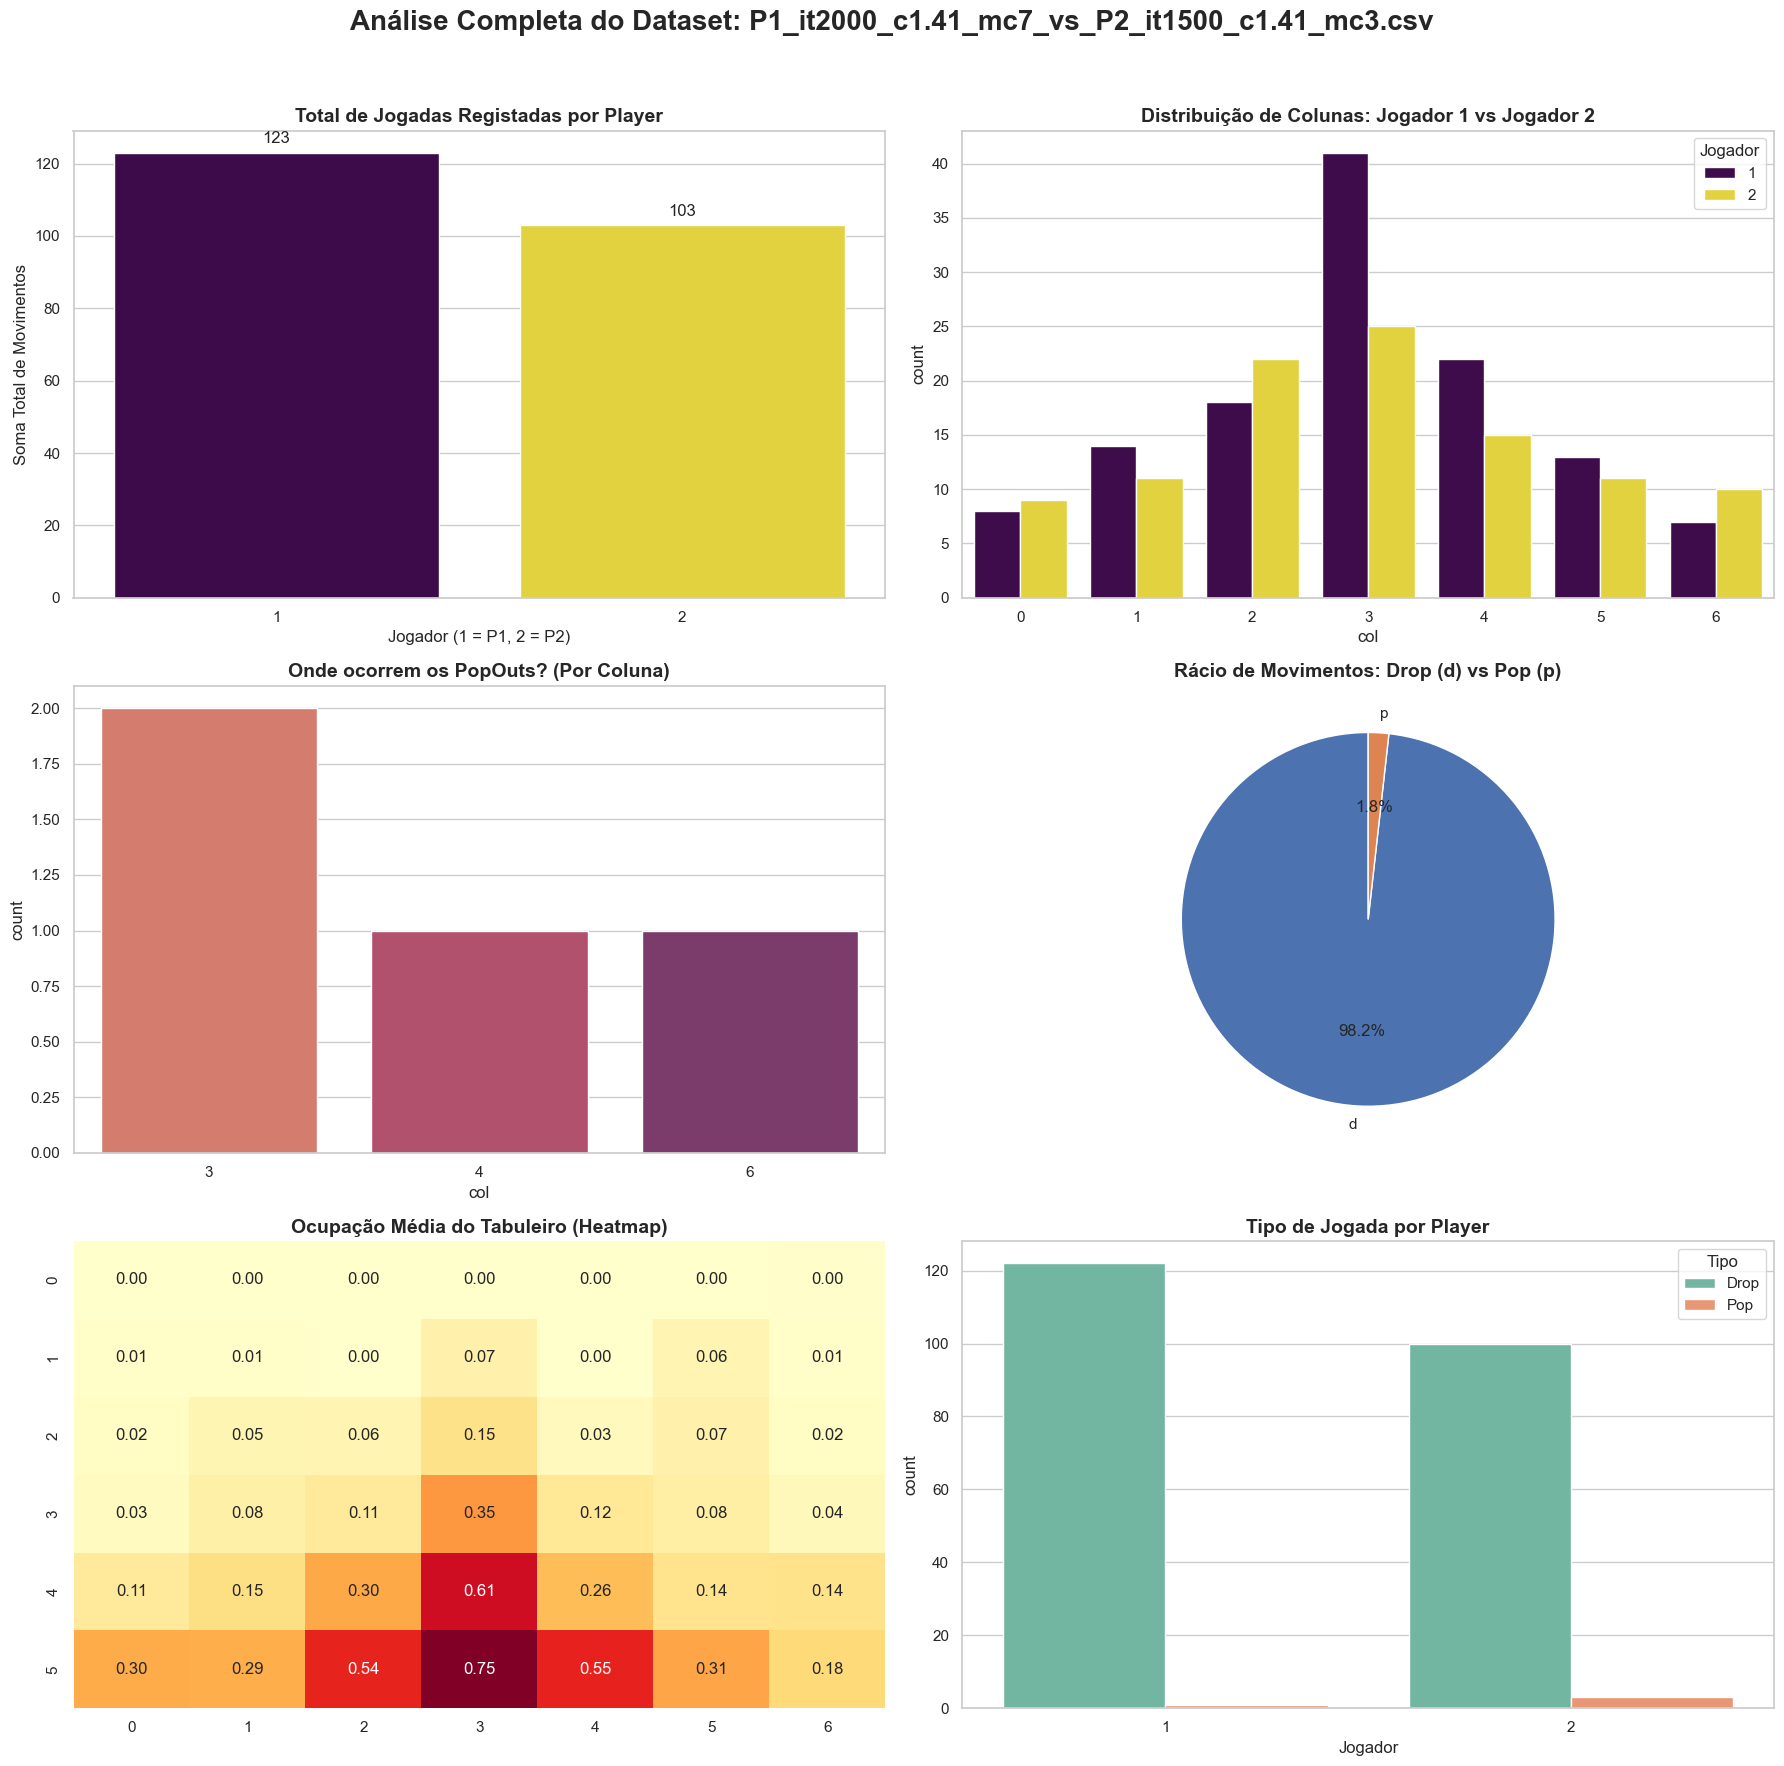

In [25]:
# ==========================================
# 1. CARREGAMENTO
# ==========================================
caminho_ficheiro = r"E:\FCUP\IA\datasets\P1_it2000_c1.41_mc7_vs_P2_it1500_c1.41_mc3.csv"
nome_do_ficheiro = os.path.basename(caminho_ficheiro)
df = pd.read_csv(caminho_ficheiro)

# ==========================================
# 2. CONFIGURAR DASHBOARD 3x2
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

fig.suptitle(f"Análise Completa do Dataset: {nome_do_ficheiro}", fontsize=20, fontweight='bold', y=0.98)

# --- QUADRANTE 1: TOTAL DE JOGADAS POR JOGADOR (O que pediste) ---
sns.countplot(data=df, x='p_turn', ax=axes[0, 0], palette=['#440154', '#fde725'])
axes[0, 0].set_title("Total de Jogadas Registadas por Player", fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel("Jogador (1 = P1, 2 = P2)")
axes[0, 0].set_ylabel("Soma Total de Movimentos")
# Adicionar os números exatos por cima das barras
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')

# --- QUADRANTE 2: Escolha de Colunas (P1 vs P2) ---
sns.countplot(data=df, x='col', hue='p_turn', ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title("Distribuição de Colunas: Jogador 1 vs Jogador 2", fontsize=14, fontweight='bold')
axes[0, 1].legend(title="Jogador")

# --- QUADRANTE 3: Uso do PopOut por Coluna ---
pops_df = df[df['type'] == 'p']
if not pops_df.empty:
    sns.countplot(data=pops_df, x='col', ax=axes[1, 0], palette='flare')
    axes[1, 0].set_title("Onde ocorrem os PopOuts? (Por Coluna)", fontsize=14, fontweight='bold')
else:
    axes[1, 0].text(0.5, 0.5, "Nenhuma jogada 'Pop' no dataset", ha='center', va='center')

# --- QUADRANTE 4: Proporção Global Drop vs Pop ---
contagem_tipos = df['type'].value_counts()
axes[1, 1].pie(contagem_tipos, labels=contagem_tipos.index, autopct='%1.1f%%', 
               colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1, 1].set_title("Rácio de Movimentos: Drop (d) vs Pop (p)", fontsize=14, fontweight='bold')

# --- QUADRANTE 5: Mapa de Calor de Ocupação ---
colunas_tab = [f"pos_{i}" for i in range(42)]
ocupacao = (df[colunas_tab] > 0).mean().values.reshape(6, 7)
sns.heatmap(ocupacao, annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[2, 0], cbar=False)
axes[2, 0].set_title("Ocupação Média do Tabuleiro (Heatmap)", fontsize=14, fontweight='bold')

# --- QUADRANTE 6: Frequência por Jogador e Tipo ---
sns.countplot(data=df, x='p_turn', hue='type', ax=axes[2, 1], palette='Set2')
axes[2, 1].set_title("Tipo de Jogada por Player", fontsize=14, fontweight='bold')
axes[2, 1].set_xlabel("Jogador")
axes[2, 1].legend(title="Tipo", labels=['Drop', 'Pop'])

# Ajuste final para não sobrepor
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()